# Analysis - Time Experiments

In [1]:
# SetUp

import os
import sys

# PROJ_DATA_PATH = "/opt/conda/envs/geospatial/share/proj"
PROJPATH = '/home/jovyan/projetos/proj_amazonia_dggs'
PROJBASEPATH = f'{PROJPATH}/proj_amazonia_dggs_base'

ENVPATH = f'{PROJBASEPATH}/env/proj_amazonia_dggs'
SRCPATH = f'{PROJBASEPATH}/src'

LOCALPATH = f'{PROJPATH}/amazonia_dggs_accuracy_experiments'
DATAPATH = f'{LOCALPATH}/data'
DOCPATH = f'{LOCALPATH}/docs'
LOCALSRCPATH = f'{LOCALPATH}/src'

os.environ['PROJ_DATA'] = f'{ENVPATH}/share/proj'
sys.path.append(SRCPATH)
sys.path.append(LOCALSRCPATH)

In [2]:
# Packages

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy import stats
from tqdm.notebook import tqdm

# Local packages

import analysis
import area_definitions


In [3]:
input_folder = f'{DATAPATH}/processed/experiments'
fig_output_folder =  f'{DOCPATH}/eda_experiments'

### Reading data

In [4]:
times_exp = pd.read_parquet(f'{input_folder}/time_experiment.parquet')

In [6]:
bins = area_definitions.FILTERED_BINS
categories = area_definitions.FILTERED_CATEGORIES

In [7]:
times_exp['category'] = pd.cut(times_exp['area'], bins=bins, labels=categories)   

times_exp['log_time_ivea7h'] = np.log2(times_exp['time_ivea7h'])
times_exp['log_time_rhealpix_dggal'] = np.log2(times_exp['time_rhealpix_dggal'])
times_exp['log_time_rhealpix'] = np.log2(times_exp['time_rhealpix'])

times_ivea7h = []
times_rhealpix_dggal = []
times_rhealpix = []

for cat in categories:
    tmp = times_exp.loc[times_exp.category == cat]
    times_ivea7h.append(tmp['log_time_ivea7h'].values)
    times_rhealpix_dggal.append(tmp['log_time_rhealpix_dggal'].values)
    times_rhealpix.append(tmp['log_time_rhealpix'].values)


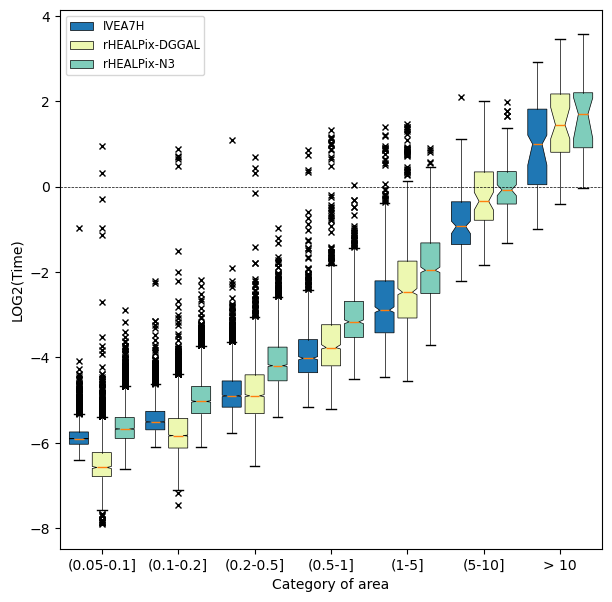

In [8]:
positions = np.linspace(1, 13, 7)

fig, ax = plt.subplots(figsize=(7, 7))



ax.boxplot(times_ivea7h,
           positions=positions-0.60,
           sym='x',
           notch=True,
           bootstrap=1000,
           patch_artist=True,
           boxprops=dict(linewidth=0.5),
           whiskerprops=dict(linewidth=0.5),
           flierprops=dict(linewidth=0.5, markersize=5),
           label='IVEA7H')

ax.boxplot(times_rhealpix_dggal,
           positions=positions,
           sym='x',
           notch=True,
           bootstrap=1000,
           patch_artist=True,
           boxprops=dict(facecolor='#edf8b1', linewidth=0.5),
           whiskerprops=dict(linewidth=0.5),
           flierprops=dict(linewidth=0.5, markersize=5),
           label='rHEALPix-DGGAL')

ax.boxplot(times_rhealpix,
           positions=positions+0.60,
           sym='x',
           notch=True,
           bootstrap=1000,
           patch_artist=True,
           boxprops=dict(facecolor='#7fcdbb', linewidth=0.5),
           whiskerprops=dict(linewidth=0.5),
           flierprops=dict(linewidth=0.5, markersize=5),
           label='rHEALPix')

ax.axhline(y=0, linewidth=0.5, linestyle='dashed', color='black')

ax.legend(fontsize='small')
ax.set_xticks(positions)
ax.set_xticklabels(categories)
ax.set_ylabel('LOG2(Time)')
# ax.set_yscale('log')
ax.set_xlabel('Category of area')
plt.savefig(f'{fig_output_folder}/time_exp.png', bbox_inches='tight')